# Region embeddings from seqlet annotations

Seqlet-level information aggregated back to the regions the seqlets came from.

Needs a clustered seqlet AnnData from the previous tutorials, with:

- `obsm["X_pca"]` (written by {func}`~tfmindi.tl.embed_and_cluster`) for the default `"pca"` embedding
- `obs["attribution"]` for the attribution-weighted embedding (default, recommended)
- an annotation column in `.obs` for count-vector embeddings and region profiles
- a column grouping regions, e.g. `obs["cell_type"]`, to find an optimal clustering

In [1]:
import tfmindi as tm
%matplotlib inline

/data/groups/vib.ai/stein.aerts/dabaffy/software/conda_envs/tfmindi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seqlet_adata = tm.load_h5ad("tutorial_data/seqlets_clustered.h5ad")

The attribution, cell type and annotation columns:

In [3]:
seqlet_adata.obs[["attribution", "cell_type", "predicted_5.0_predicted_family_reranked"]].head()

,attribution,cell_type,predicted_5.0_predicted_family_reranked
0,11.616397,Astro,CTF_NFI
1,8.770116,Astro,CTF_NFI
2,8.682135,Astro,CTF_NFI
3,3.131226,Astro,bHLH
4,11.107230,Astro,Homeobox


## Region embeddings from the seqlet PCA

{func}`~tfmindi.tl.embed_regions` averages each region's seqlet PCA coordinates, weighted by
attribution, and computes a t-SNE on the result.

In [4]:
region_adata = tm.tl.embed_regions(seqlet_adata)

 [embed] embedding='pca', secondary='50', weighted, normalised
 [embed] Calculating weights
 [embed] Calculating pca embeddings on obsm.X_pca
 [embed] Calculating TSNE reduction...
[2026-08-26 05:54:42.789] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


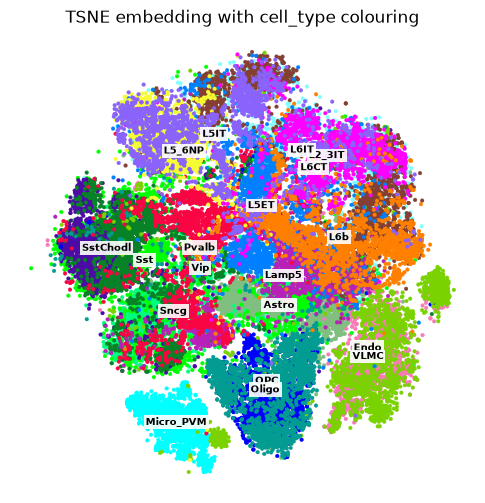

In [5]:
palette = tm.pl.region_tsne(region_adata)

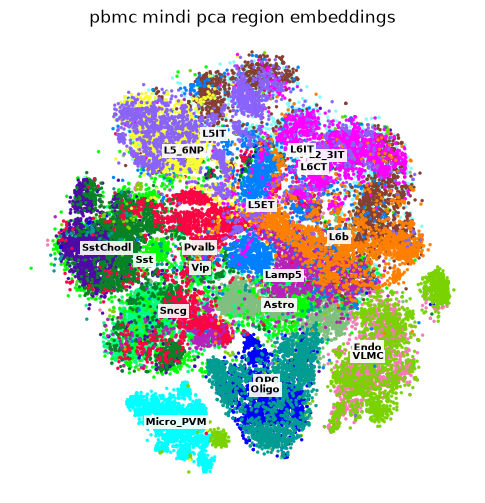

In [6]:
_ = tm.pl.region_tsne(
    region_adata,
    obsm_key="TSNE",
    color_by="cell_type",
    title="pbmc mindi pca region embeddings",
    plot_legend=False,
    plot_labels=True,
    palette=palette,
    fig_edge=6,
    dot_size=5,
    clean=True,
)

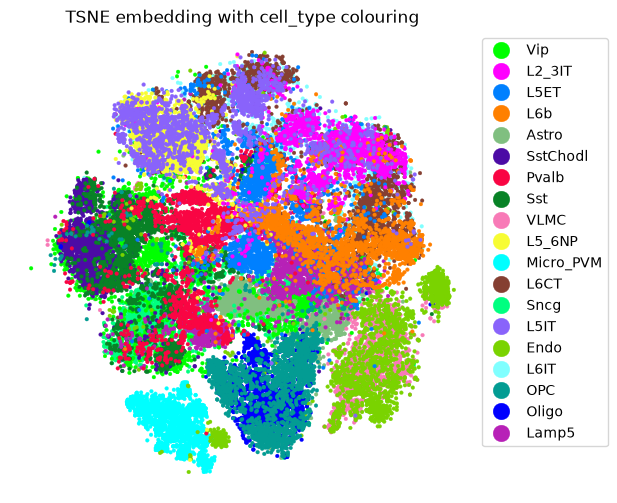

In [7]:
_ = tm.pl.region_tsne(region_adata, plot_legend=True, plot_labels=False, palette=palette)

## Count vector embeddings

Instead of averaging coordinates, count how often each annotation occurs per region.

In [8]:
region_adata_count = tm.tl.embed_regions(
    seqlet_adata,
    embedding="count",
    secondary="predicted_5.0_predicted_family_reranked",
    normalised=False,
)

 [embed] embedding='count', secondary='predicted_5.0_predicted_family_reranked', weighted, unnormalised
 [embed] Calculating weights
 [embed] Calculating count embeddings by constructing count vectors at adata.obs['predicted_5.0_predicted_family_reranked'] resolution
 [embed] Calculating TSNE reduction...
[2026-08-26 05:54:44.859] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


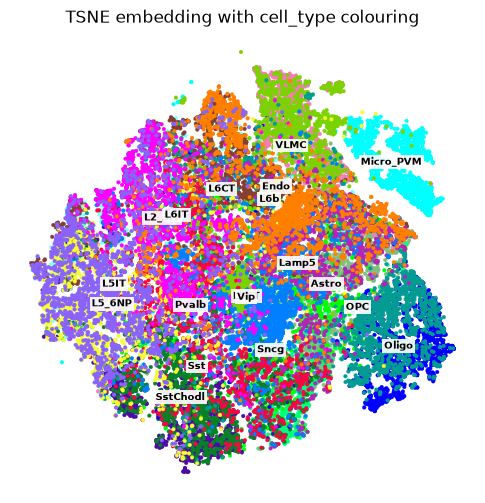

In [9]:
_ = tm.pl.region_tsne(region_adata_count, palette=palette)

## Finding the best clustering of the embeddings

{func}`~tfmindi.tl.optimal_hierarchical_clustering` sweeps cut heights and keeps the one whose
clusters best agree with an existing region label (here `cell_type`).

 [clustering] Seeding embedding space with leiden clusters...
 [clustering] Build hierarchical tree...
 [clustering] Cutting at height 0.99
 [clustering] The optimal resolution is 0.31 with an ARI of 0.38591643576853135
 [clustering] Saved clusters in .obs region_cluster
 [clustering] Plotting...


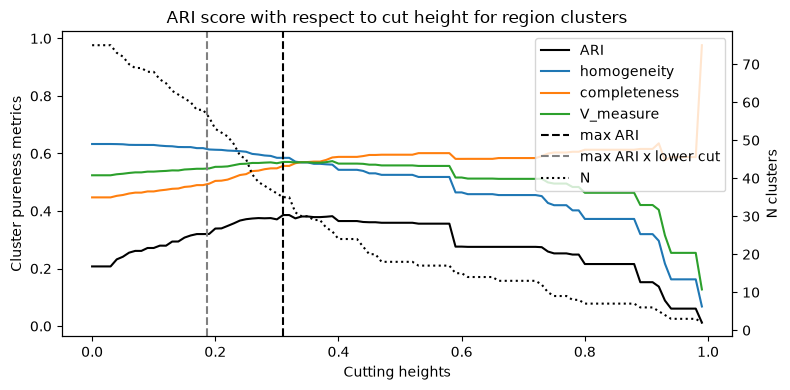

In [10]:
tm.tl.optimal_hierarchical_clustering(region_adata, lower_cut=0.6)

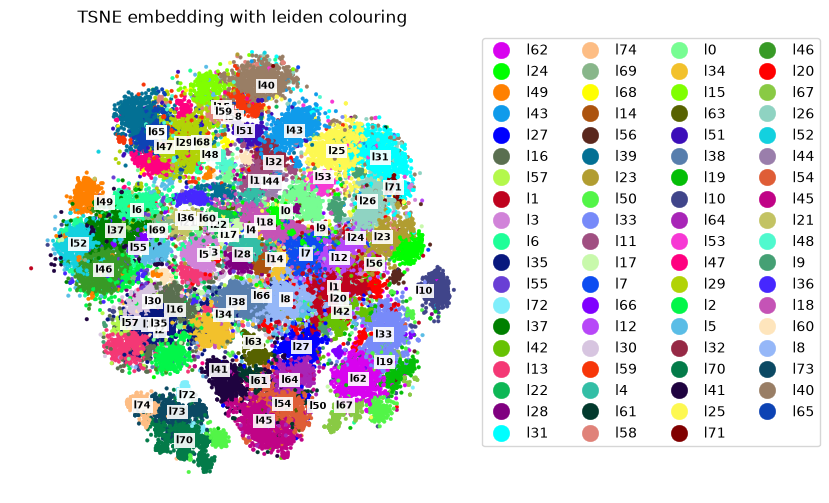

In [11]:
_ = tm.pl.region_tsne(region_adata, color_by="leiden", plot_legend=True, plot_labels=True)

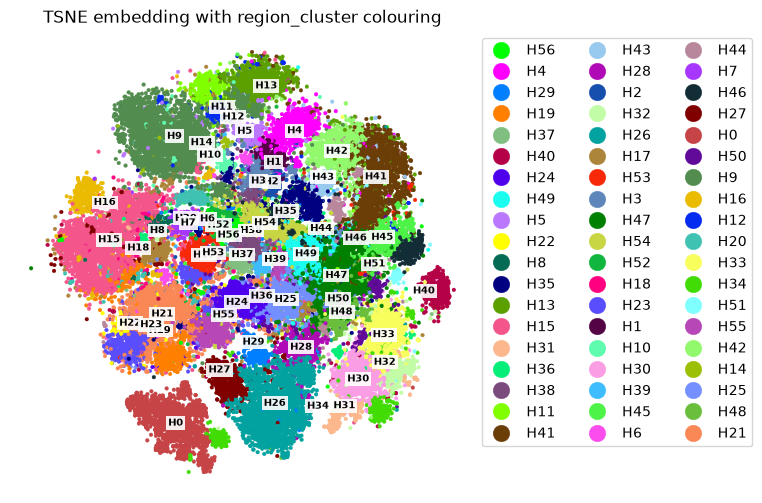

In [12]:
_ = tm.pl.region_tsne(region_adata, color_by="region_cluster", plot_legend=True, plot_labels=True)

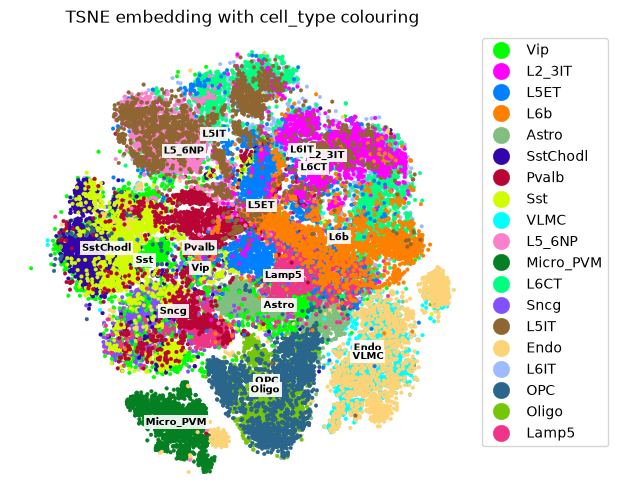

In [13]:
_ = tm.pl.region_tsne(region_adata, plot_legend=True, plot_labels=True)

## Region cluster profiles

Which motifs drive each region cluster.

In [14]:
profiles = tm.tl.get_region_profiles(
    seqlet_adata,
    region_adata,
    annotation_col="predicted_5.0_predicted_family_reranked",
    region_cluster_col="region_cluster",
)

/data/groups/vib.ai/stein.aerts/dabaffy/software/conda_envs/tfmindi/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


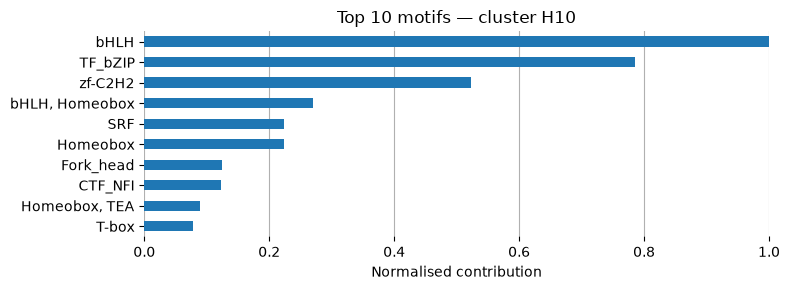

In [15]:
tm.pl.plot_top_motifs(profiles, region_cluster="H10")

## Save the region object

In [16]:
tm.save_h5ad(region_adata, "tutorial_data/regions.h5ad")

... storing 'leiden' as categorical
... storing 'region_cluster' as categorical
